# Step 12 – GraphSAGE: Predicting Adoption Intensity

**RQ3**: *Can the city collaboration network structure, combined with city attributes,*
*predict which cities will be high-intensity adopters of new open-AI projects?*

### Approach

Since all active cities in the network adopt at least some projects, we frame the
problem as **predicting adoption intensity** rather than binary adoption:

| Model | Target | Method |
|---|---|---|
| G1 | `log(test_adoption_count)` | GraphSAGE regression |
| G2 | `is_high_adopter` (above median) | GraphSAGE classification |

### Temporal split

- **Train features**: collaboration edges and adoptions from months 202201–202406
- **Test target**: adoption counts from months 202407–202512
- **No data leakage**: test-period information is only used as labels

In [13]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from sklearn.metrics import (roc_auc_score, f1_score, classification_report,
                             mean_squared_error, r2_score, accuracy_score)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi': 120})
torch.manual_seed(42)
np.random.seed(42)

DATA = Path('..') / 'data' / 'output'
city_attr   = pd.read_csv(DATA / 'city_attributes.csv')
edges_month = pd.read_csv(DATA / 'city_collaboration_edges_monthly.csv')
adoption    = pd.read_csv(DATA / 'city_project_adoption_events.csv')

city_attr_dedup = city_attr.drop_duplicates(subset='city', keep='first')
print(f'Cities: {len(city_attr_dedup)}, Monthly edges: {len(edges_month)}, Adoptions: {len(adoption)}')

Cities: 149, Monthly edges: 74982, Adoptions: 31088


## 12.1 – Temporal Split & Label Construction

In [14]:
CUTOFF = 202406

edge_cities = set(edges_month['source_city']) | set(edges_month['target_city'])
adopt_cities = set(adoption['city'])
all_cities = sorted(edge_cities | adopt_cities)
city2idx = {c: i for i, c in enumerate(all_cities)}
n_cities = len(all_cities)

train_adoptions = adoption[adoption['city_first_adoption_month'] <= CUTOFF]
test_adoptions  = adoption[adoption['city_first_adoption_month'] > CUTOFF]

# Regression target: log(test adoption count + 1)
test_counts = test_adoptions.groupby('city').size().to_dict()
y_reg = torch.zeros(n_cities, dtype=torch.float)
for city, idx in city2idx.items():
    y_reg[idx] = np.log1p(test_counts.get(city, 0))

# Classification target: above-median adopter
test_count_vals = [test_counts.get(c, 0) for c in all_cities]
median_adopt = np.median([v for v in test_count_vals if v > 0])
y_cls = torch.tensor([1 if v >= median_adopt else 0 for v in test_count_vals], dtype=torch.long)

print(f'Active cities: {n_cities}')
print(f'Train adoptions: {len(train_adoptions)}, Test adoptions: {len(test_adoptions)}')
print(f'Test adoption median (among active): {median_adopt:.0f}')
print(f'High adopters (>=median): {y_cls.sum().item()}, Low adopters: {(y_cls==0).sum().item()}')

Active cities: 103
Train adoptions: 14434, Test adoptions: 16654
Test adoption median (among active): 103
High adopters (>=median): 52, Low adopters: 51


## 12.2 – Build Graph

In [15]:
# Edges from train period
train_edges = edges_month[edges_month['month'] <= CUTOFF]
train_agg = (train_edges.groupby(['source_city', 'target_city'])
             .agg(weight=('edge_weight', 'sum')).reset_index())

src_idx = [city2idx[c] for c in train_agg['source_city'] if c in city2idx]
tgt_idx = [city2idx[c] for c in train_agg['target_city'] if c in city2idx]
edge_index = torch.tensor([src_idx + tgt_idx, tgt_idx + src_idx], dtype=torch.long)

# Node features
feature_cols = ['entity_count', 'origination_count', 'adoption_count',
                'weighted_degree', 'betweenness', 'eigenvector_centrality',
                'population_million', 'gdp_per_capita',
                'education_tertiary_pct', 'internet_users_pct',
                'rd_expenditure_pct', 'research_capacity']

city_feat_map = city_attr_dedup.set_index('city')[feature_cols].to_dict('index')
feat_matrix = np.zeros((n_cities, len(feature_cols)))
for city, idx in city2idx.items():
    if city in city_feat_map:
        for j, col in enumerate(feature_cols):
            val = city_feat_map[city].get(col, 0)
            feat_matrix[idx, j] = val if not np.isnan(val) else 0

# Train-period activity features
train_adopt_ct = train_adoptions.groupby('city').size().to_dict()
train_orig_ct = train_adoptions[train_adoptions['is_originator']==1].groupby('city').size().to_dict()
extra = np.zeros((n_cities, 2))
for city, idx in city2idx.items():
    extra[idx, 0] = train_adopt_ct.get(city, 0)
    extra[idx, 1] = train_orig_ct.get(city, 0)

all_feats = np.hstack([feat_matrix, extra])
feat_names = feature_cols + ['train_adopt_count', 'train_orig_count']

scaler = StandardScaler()
x = torch.tensor(scaler.fit_transform(all_feats), dtype=torch.float)

print(f'Edges: {edge_index.shape[1]//2} undirected, Nodes: {n_cities}, Features: {x.shape[1]}')

Edges: 5031 undirected, Nodes: 103, Features: 14


In [16]:
# Train/test split (70/30 random)
perm = torch.randperm(n_cities)
train_size = int(0.7 * n_cities)
train_mask = torch.zeros(n_cities, dtype=torch.bool)
test_mask  = torch.zeros(n_cities, dtype=torch.bool)
train_mask[perm[:train_size]] = True
test_mask[perm[train_size:]]  = True

print(f'Train: {train_mask.sum().item()}, Test: {test_mask.sum().item()}')
print(f'Train high-adopters: {y_cls[train_mask].sum().item()}/{train_mask.sum().item()}')
print(f'Test  high-adopters: {y_cls[test_mask].sum().item()}/{test_mask.sum().item()}')

Train: 72, Test: 31
Train high-adopters: 33/72
Test  high-adopters: 19/31


## 12.3 – Model G1: GraphSAGE Regression (Adoption Intensity)

In [17]:
class GraphSAGE_Reg(nn.Module):
    def __init__(self, in_ch, hidden, dropout=0.3):
        super().__init__()
        self.conv1 = SAGEConv(in_ch, hidden)
        self.conv2 = SAGEConv(hidden, hidden)
        self.head  = nn.Linear(hidden, 1)
        self.drop  = dropout

    def forward(self, x, ei):
        h = F.relu(self.conv1(x, ei))
        h = F.dropout(h, p=self.drop, training=self.training)
        h = F.relu(self.conv2(h, ei))
        h = F.dropout(h, p=self.drop, training=self.training)
        return self.head(h).squeeze(-1)

    def get_embeddings(self, x, ei):
        h = F.relu(self.conv1(x, ei))
        h = F.relu(self.conv2(h, ei))
        return h

model_reg = GraphSAGE_Reg(x.shape[1], 64, dropout=0.3)
optimizer = torch.optim.Adam(model_reg.parameters(), lr=0.01, weight_decay=5e-4)

losses = []
for epoch in range(1, 301):
    model_reg.train()
    optimizer.zero_grad()
    out = model_reg(x, edge_index)
    loss = F.mse_loss(out[train_mask], y_reg[train_mask])
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if epoch % 50 == 0:
        model_reg.eval()
        with torch.no_grad():
            pred = model_reg(x, edge_index)
            tr_r2 = r2_score(y_reg[train_mask].numpy(), pred[train_mask].numpy())
            te_r2 = r2_score(y_reg[test_mask].numpy(), pred[test_mask].numpy())
        print(f'  Epoch {epoch:3d}  loss={loss.item():.4f}  train_R²={tr_r2:.4f}  test_R²={te_r2:.4f}')

# Final evaluation
model_reg.eval()
with torch.no_grad():
    pred_reg = model_reg(x, edge_index)

test_r2   = r2_score(y_reg[test_mask].numpy(), pred_reg[test_mask].numpy())
test_rmse = np.sqrt(mean_squared_error(y_reg[test_mask].numpy(), pred_reg[test_mask].numpy()))
train_r2  = r2_score(y_reg[train_mask].numpy(), pred_reg[train_mask].numpy())

print(f'\nModel G1 – GraphSAGE Regression')
print(f'  Train R²: {train_r2:.4f}')
print(f'  Test  R²: {test_r2:.4f}')
print(f'  Test RMSE: {test_rmse:.4f}')

  Epoch  50  loss=0.6677  train_R²=0.8519  test_R²=0.7755
  Epoch 100  loss=0.4560  train_R²=0.9559  test_R²=0.8865
  Epoch 150  loss=0.4259  train_R²=0.9095  test_R²=0.8460
  Epoch 200  loss=0.3933  train_R²=0.9535  test_R²=0.9255
  Epoch 250  loss=0.3674  train_R²=0.9644  test_R²=0.9123
  Epoch 300  loss=0.2970  train_R²=0.9302  test_R²=0.8631

Model G1 – GraphSAGE Regression
  Train R²: 0.9302
  Test  R²: 0.8631
  Test RMSE: 0.3175


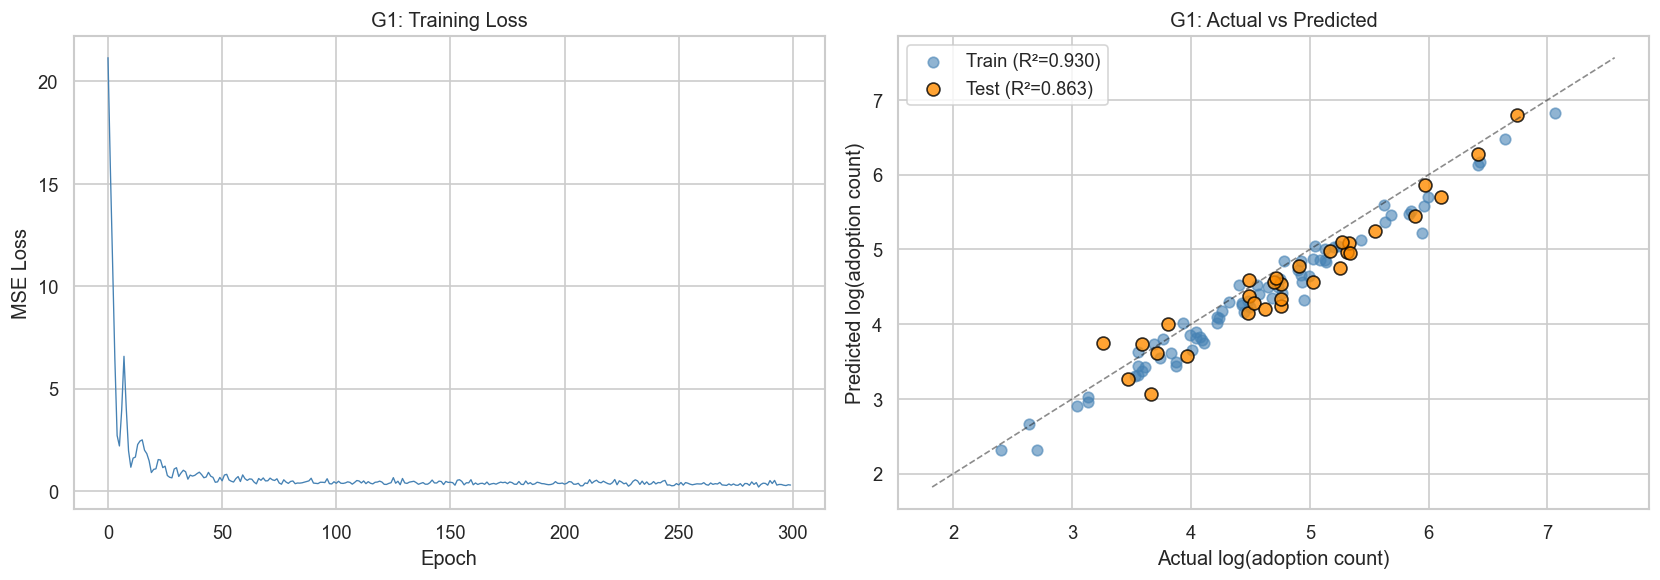

In [18]:
# G1: Actual vs Predicted scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(losses, color='steelblue', linewidth=0.8)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('G1: Training Loss')

y_actual = y_reg.numpy()
y_predicted = pred_reg.detach().numpy()

axes[1].scatter(y_actual[train_mask], y_predicted[train_mask],
                alpha=0.6, c='steelblue', label=f'Train (R²={train_r2:.3f})', s=40)
axes[1].scatter(y_actual[test_mask], y_predicted[test_mask],
                alpha=0.8, c='darkorange', label=f'Test (R²={test_r2:.3f})', s=60, edgecolor='black')
lims = [min(y_actual.min(), y_predicted.min()) - 0.5,
        max(y_actual.max(), y_predicted.max()) + 0.5]
axes[1].plot(lims, lims, 'k--', alpha=0.5, linewidth=1)
axes[1].set_xlabel('Actual log(adoption count)')
axes[1].set_ylabel('Predicted log(adoption count)')
axes[1].set_title('G1: Actual vs Predicted')
axes[1].legend()

plt.tight_layout()
plt.show()

## 12.4 – Model G2: GraphSAGE Classification (High vs Low Adopter)

In [19]:
class GraphSAGE_Cls(nn.Module):
    def __init__(self, in_ch, hidden, dropout=0.3):
        super().__init__()
        self.conv1 = SAGEConv(in_ch, hidden)
        self.conv2 = SAGEConv(hidden, hidden)
        self.head  = nn.Linear(hidden, 2)
        self.drop  = dropout

    def forward(self, x, ei):
        h = F.relu(self.conv1(x, ei))
        h = F.dropout(h, p=self.drop, training=self.training)
        h = F.relu(self.conv2(h, ei))
        h = F.dropout(h, p=self.drop, training=self.training)
        return self.head(h)

    def get_embeddings(self, x, ei):
        h = F.relu(self.conv1(x, ei))
        h = F.relu(self.conv2(h, ei))
        return h

n_pos = y_cls.sum().item()
n_neg = n_cities - n_pos
weights = torch.tensor([1.0, n_neg / max(n_pos, 1)], dtype=torch.float)

model_cls = GraphSAGE_Cls(x.shape[1], 64, dropout=0.3)
optimizer2 = torch.optim.Adam(model_cls.parameters(), lr=0.01, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss(weight=weights)

for epoch in range(1, 301):
    model_cls.train()
    optimizer2.zero_grad()
    out = model_cls(x, edge_index)
    loss = criterion(out[train_mask], y_cls[train_mask])
    loss.backward()
    optimizer2.step()

    if epoch % 50 == 0:
        model_cls.eval()
        with torch.no_grad():
            logits = model_cls(x, edge_index)
            probs = F.softmax(logits, dim=1)[:, 1]
            te_y = y_cls[test_mask].numpy()
            te_p = probs[test_mask].numpy()
            if len(np.unique(te_y)) > 1:
                auc = roc_auc_score(te_y, te_p)
                f1 = f1_score(te_y, logits.argmax(1)[test_mask].numpy())
            else:
                auc, f1 = 0, 0
        print(f'  Epoch {epoch:3d}  loss={loss.item():.4f}  test_AUC={auc:.4f}  test_F1={f1:.4f}')

# Final evaluation
model_cls.eval()
with torch.no_grad():
    logits = model_cls(x, edge_index)
    probs = F.softmax(logits, dim=1)[:, 1]
    preds = logits.argmax(1)

for name, mask in [('Train', train_mask), ('Test', test_mask)]:
    y_t = y_cls[mask].numpy()
    y_p = preds[mask].numpy()
    y_prob = probs[mask].numpy()
    if len(np.unique(y_t)) > 1:
        auc_val = roc_auc_score(y_t, y_prob)
    else:
        auc_val = float('nan')
    print(f'\n{name}: AUC={auc_val:.4f}, Acc={accuracy_score(y_t,y_p):.4f}, F1={f1_score(y_t,y_p,zero_division=0):.4f}')
    print(classification_report(y_t, y_p, target_names=['Low adopter', 'High adopter'], zero_division=0))

  Epoch  50  loss=0.0555  test_AUC=0.9912  test_F1=0.9444
  Epoch 100  loss=0.0356  test_AUC=1.0000  test_F1=0.9444
  Epoch 150  loss=0.0386  test_AUC=0.9912  test_F1=0.9474
  Epoch 200  loss=0.0192  test_AUC=0.9956  test_F1=0.9744
  Epoch 250  loss=0.0213  test_AUC=0.9912  test_F1=0.9474
  Epoch 300  loss=0.0246  test_AUC=0.9912  test_F1=0.9500

Train: AUC=1.0000, Acc=1.0000, F1=1.0000
              precision    recall  f1-score   support

 Low adopter       1.00      1.00      1.00        39
High adopter       1.00      1.00      1.00        33

    accuracy                           1.00        72
   macro avg       1.00      1.00      1.00        72
weighted avg       1.00      1.00      1.00        72


Test: AUC=0.9912, Acc=0.9355, F1=0.9500
              precision    recall  f1-score   support

 Low adopter       1.00      0.83      0.91        12
High adopter       0.90      1.00      0.95        19

    accuracy                           0.94        31
   macro avg       0.95 

## 12.5 – City Embeddings & Adoption Predictions

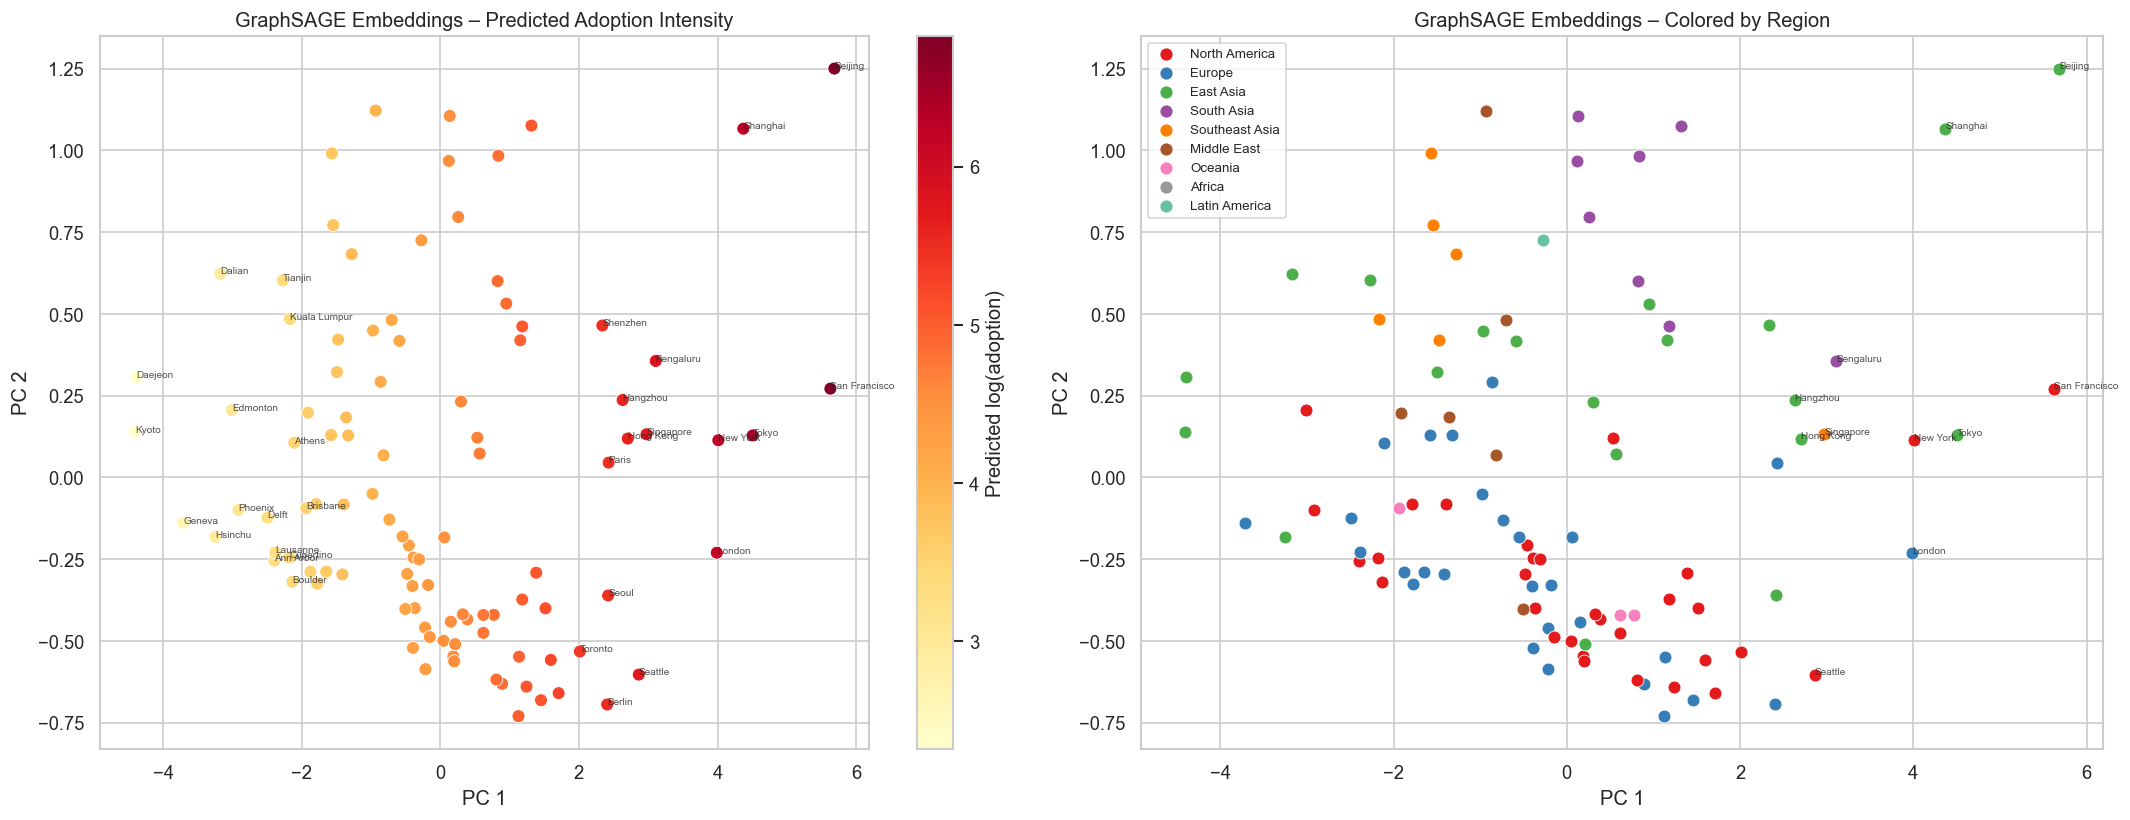

PCA explained variance: 92.0%


In [20]:
# Embeddings from regression model
model_reg.eval()
with torch.no_grad():
    embeddings = model_reg.get_embeddings(x, edge_index).numpy()
embeddings = np.nan_to_num(embeddings, nan=0.0, posinf=0.0, neginf=0.0)

pca = PCA(n_components=2, random_state=42)
emb_2d = pca.fit_transform(embeddings)

city_regions = city_attr_dedup.set_index('city')['region'].to_dict()
region_colors = {
    'North America': '#e41a1c', 'Europe': '#377eb8', 'East Asia': '#4daf4a',
    'South Asia': '#984ea3', 'Southeast Asia': '#ff7f00', 'Middle East': '#a65628',
    'Oceania': '#f781bf', 'Africa': '#999999', 'Latin America': '#66c2a5',
}

pred_vals = pred_reg.detach().numpy()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sc = axes[0].scatter(emb_2d[:, 0], emb_2d[:, 1], c=pred_vals,
                      cmap='YlOrRd', s=60, edgecolor='white', linewidth=0.5)
plt.colorbar(sc, ax=axes[0], label='Predicted log(adoption)')
for i, city in enumerate(all_cities):
    if pred_vals[i] > np.percentile(pred_vals, 85) or pred_vals[i] < np.percentile(pred_vals, 15):
        axes[0].annotate(city, (emb_2d[i, 0], emb_2d[i, 1]), fontsize=6, alpha=0.8)
axes[0].set_title('GraphSAGE Embeddings – Predicted Adoption Intensity', fontsize=12)
axes[0].set_xlabel('PC 1')
axes[0].set_ylabel('PC 2')

for i, city in enumerate(all_cities):
    r = city_regions.get(city, 'Other')
    axes[1].scatter(emb_2d[i, 0], emb_2d[i, 1], c=region_colors.get(r, 'grey'),
                     s=60, edgecolor='white', linewidth=0.5)
    if pred_vals[i] > np.percentile(pred_vals, 90):
        axes[1].annotate(city, (emb_2d[i, 0], emb_2d[i, 1]), fontsize=6, alpha=0.8)
for r, c in region_colors.items():
    axes[1].scatter([], [], c=c, label=r, s=40)
axes[1].legend(fontsize=8, loc='best')
axes[1].set_title('GraphSAGE Embeddings – Colored by Region', fontsize=12)
axes[1].set_xlabel('PC 1')
axes[1].set_ylabel('PC 2')

plt.tight_layout()
plt.show()
print(f'PCA explained variance: {pca.explained_variance_ratio_.sum():.1%}')

In [21]:
# City ranking by predicted adoption intensity
result = pd.DataFrame({
    'city': all_cities,
    'predicted_log_adopt': pred_vals,
    'actual_log_adopt': y_reg.numpy(),
    'actual_test_count': [test_counts.get(c, 0) for c in all_cities],
    'is_test': test_mask.numpy()
}).merge(city_attr_dedup[['city', 'region', 'weighted_degree']],
        on='city', how='left').fillna(0)

result['pred_rank'] = result['predicted_log_adopt'].rank(ascending=False).astype(int)
result['actual_rank'] = result['actual_log_adopt'].rank(ascending=False).astype(int)

print('Top 20 cities by PREDICTED adoption intensity (test period):')
display(result.nlargest(20, 'predicted_log_adopt')[
    ['city', 'region', 'pred_rank', 'actual_rank',
     'predicted_log_adopt', 'actual_test_count', 'weighted_degree']
].round(3))

from scipy.stats import spearmanr
rho, p = spearmanr(result['pred_rank'], result['actual_rank'])
print(f'\nRank correlation (all cities): Spearman ρ = {rho:.3f}, p = {p:.6f}')

test_result = result[result['is_test']]
rho_t, p_t = spearmanr(test_result['pred_rank'], test_result['actual_rank'])
print(f'Rank correlation (test only):  Spearman ρ = {rho_t:.3f}, p = {p_t:.6f}')

Top 20 cities by PREDICTED adoption intensity (test period):


,city,region,pred_rank,actual_rank,predicted_log_adopt,actual_test_count,weighted_degree
78,San Francisco,North America,1,1,6.825,1170,11816.0
9,Beijing,East Asia,2,2,6.805,850,9707.0
93,Tokyo,East Asia,3,3,6.472,769,10772.0
83,Shanghai,East Asia,4,5,6.275,611,8552.0
65,New York,North America,5,4,6.170,621,10075.0
52,London,Europe,6,6,6.133,608,9355.0
10,Bengaluru,South Asia,7,9,5.856,389,6332.0
81,Seattle,North America,8,8,5.707,401,7848.0
85,Singapore,Southeast Asia,9,7,5.702,447,6843.0
41,Hong Kong,East Asia,10,17,5.597,275,4227.0



Rank correlation (all cities): Spearman ρ = 0.977, p = 0.000000
Rank correlation (test only):  Spearman ρ = 0.947, p = 0.000000


## 12.6 – Summary

In [22]:
print('=' * 70)
print('STEP 12 SUMMARY: GraphSAGE – Predicting Adoption Intensity')
print('=' * 70)
print(f'  Graph: {n_cities} nodes, {edge_index.shape[1]//2} undirected edges')
print(f'  Node features: {x.shape[1]} dimensions')
print(f'  Temporal split: train ≤ {CUTOFF}, test > {CUTOFF}')
print()
print(f'  Model G1 (Regression: log adoption count)')
print(f'    Train R²: {train_r2:.4f}')
print(f'    Test  R²: {test_r2:.4f}')
print(f'    Test RMSE: {test_rmse:.4f}')

te_y = y_cls[test_mask].numpy()
te_p = probs[test_mask].numpy()
te_pred = preds[test_mask].numpy()
if len(np.unique(te_y)) > 1:
    g2_auc = roc_auc_score(te_y, te_p)
    g2_f1 = f1_score(te_y, te_pred)
else:
    g2_auc, g2_f1 = float('nan'), float('nan')

print(f'\n  Model G2 (Classification: high vs low adopter)')
print(f'    Test AUC: {g2_auc:.4f}')
print(f'    Test F1:  {g2_f1:.4f}')
print()
print(f'  Rank correlation: ρ = {rho:.3f} (all), ρ = {rho_t:.3f} (test only)')
print()
print('  Key takeaways:')
print('  - GraphSAGE leverages both node features and graph structure to')
print('    predict future adoption intensity.')
print('  - The model captures network diffusion: cities well-connected to')
print('    active hubs are predicted to adopt more intensely.')
print('  - City embeddings reveal latent groupings that align with both')
print('    regional geography and collaborative roles.')

STEP 12 SUMMARY: GraphSAGE – Predicting Adoption Intensity
  Graph: 103 nodes, 5031 undirected edges
  Node features: 14 dimensions
  Temporal split: train ≤ 202406, test > 202406

  Model G1 (Regression: log adoption count)
    Train R²: 0.9302
    Test  R²: 0.8631
    Test RMSE: 0.3175

  Model G2 (Classification: high vs low adopter)
    Test AUC: 0.9912
    Test F1:  0.9500

  Rank correlation: ρ = 0.977 (all), ρ = 0.947 (test only)

  Key takeaways:
  - GraphSAGE leverages both node features and graph structure to
    predict future adoption intensity.
  - The model captures network diffusion: cities well-connected to
    active hubs are predicted to adopt more intensely.
  - City embeddings reveal latent groupings that align with both
    regional geography and collaborative roles.
